Importing all the packages

In [54]:
import pandas as pd
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

CSV file

In [55]:
df=pd.read_csv("/content/drive/MyDrive/financial fraud detection/bank_transactions_data_2.csv")
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [56]:
features = ['TransactionAmount','Channel','CustomerAge','CustomerOccupation','AccountBalance','LoginAttempts','TransactionDuration',]

In [57]:
df=df[features].dropna()
df

,TransactionAmount,Channel,CustomerAge,CustomerOccupation,AccountBalance,LoginAttempts,TransactionDuration
0,14.09,ATM,70,Doctor,5112.21,1,81
1,376.24,ATM,68,Doctor,13758.91,1,141
2,126.29,Online,19,Student,1122.35,1,56
3,184.50,Online,26,Student,8569.06,1,25
4,13.45,Online,26,Student,7429.40,1,198
...,...,...,...,...,...,...,...
2507,856.21,Branch,33,Doctor,12690.79,1,109
2508,251.54,Branch,48,Doctor,254.75,1,177
2509,28.63,Branch,56,Retired,3382.91,1,146
2510,185.97,Online,23,Student,1776.91,1,19


Define columns by type

In [58]:
categorical_feats=['Channel','CustomerOccupation']
numerical_feats=['TransactionAmount', 'CustomerAge', 'AccountBalance', 'LoginAttempts', 'TransactionDuration']

Preprocessing

In [59]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_feats),('cat', OneHotEncoder(drop='first'), categorical_feats),])

In [60]:
model = Pipeline([('preprocessor', preprocessor),('ocsvm', OneClassSVM( kernel='rbf', gamma='scale',nu=0.01))])

Fit the model

In [61]:
model.fit(df)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['TransactionAmount',
                                                   'CustomerAge',
                                                   'AccountBalance',
                                                   'LoginAttempts',
                                                   'TransactionDuration']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Channel',
                                                   'CustomerOccupation'])])),
                ('ocsvm', OneClassSVM(nu=0.01))])

Tranform and predict

In [62]:
X_transformed = model.named_steps['preprocessor'].transform(df)
anom_labels = model.named_steps['ocsvm'].predict(X_transformed)
anom_scores = model.named_steps['ocsvm'].score_samples(X_transformed)

In [63]:
df['Anomaly'] = anom_labels
df['AnomalyScore'] = anom_scores

Anomalies

In [64]:
anomalies = df[df['Anomaly'] == -1].copy().sort_values('AnomalyScore')
print(f"Total anomalies detected: {len(anomalies)}")
print("Top 10 anomalies:\n", anomalies.head(10))

Total anomalies detected: 45
Top 10 anomalies:
       TransactionAmount Channel  CustomerAge CustomerOccupation  \
898             1531.31  Online           18            Student   
593              139.57     ATM           19            Student   
1167             838.57     ATM           41             Doctor   
2073             441.26  Branch           58             Doctor   
41                34.02  Online           38             Doctor   
428              677.29  Online           27           Engineer   
26               246.93     ATM           23            Student   
850               23.40     ATM           46             Doctor   
1984            1512.99  Online           19            Student   
1305             859.30  Branch           78            Retired   

      AccountBalance  LoginAttempts  TransactionDuration  Anomaly  \
898           859.86              4                   62       -1   
593           271.78              3                  263       -1   
1167   

Visualization of score distribution

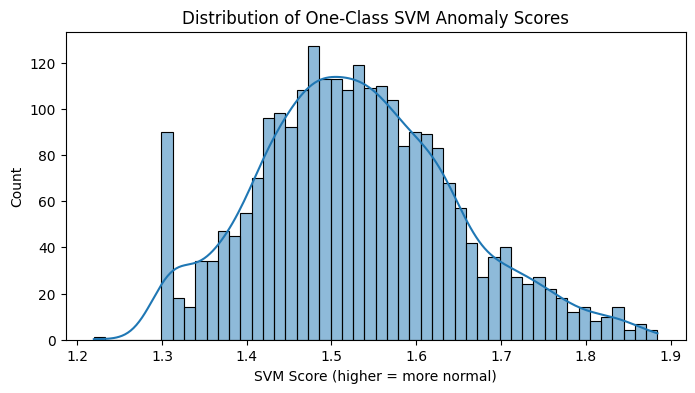

In [65]:
plt.figure(figsize=(8, 4))
sns.histplot(df['AnomalyScore'], bins=50, kde=True)
plt.title('Distribution of One-Class SVM Anomaly Scores')
plt.xlabel('SVM Score (higher = more normal)')
plt.show()